# Introduction to factors and directed factor graphs


<div class="note"><span class="note-t">TL;DR</span>
<p>We start factors with a one-pbit sampler and expand to directed factor graphs and composite factors. <code>TiledFactor</code> and <code>ChainFactor</code> keep the same sampling contract at each level, and same-key checks pin them to manual <code>vmap</code> and <code>scan</code> references.</p>
</div>

In this tutorial, we build the factor side of Torx from a single **probabilistic bit** (pbit), wire two factors into a directed factor graph, and connect that picture to the parametrised stochastic circuit (PSC) view used elsewhere in the gallery.

A **factor** is the smallest sampler on the factor side of Torx. It reads named inputs, reads parameters stored outside the object, and returns one stochastic output.

With no inputs, a factor is a plain distribution. With inputs, it is a conditional distribution.

This tutorial mirrors [notebook 01](01_introduction_to_parametrised_stochastic_circuits.ipynb) from the factor side. Along the way, we add a small **probabilistic dit** (pdit) example with $d=3$ states for exact probabilities and connect the same ideas to the 16-spin Ising model in [notebook 16](16_gibbs_sampling_factor_graph.ipynb).

Every gate the earlier notebooks built is already a factor. A `PSWAP` layer, a Gaussian gate, a `MixtureGaussianGate`, and an Ising spin update are all local conditional samplers wired to their neighbors, which is exactly what a factor is. A parametrised stochastic circuit is the circuit-shaped special case: those factors laid out on a fixed lattice of gates. The directed factor graph is the general object above it, any DAG of conditional samplers with no requirement that the wiring form a circuit. We reach it last, after fourteen circuit notebooks, because the abstraction is easiest to trust once you have built the concrete circuits it generalizes: the same constructions you already know, read one level up.



## Setup

We set up the helper path, imports, plotting style, and figure export. The notebook's two building-block types come next: `BIT` for a single pbit output (0 or 1) and `DRIVE` for a continuous value carried on an input port.

In [1]:
from pathlib import Path
import sys

import equinox as eqx
import jax
import jax.numpy as jnp
import numpy as np



In [2]:
ROOT = Path.cwd()
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
sys.path.insert(0, str(HELPER_DIR))



In [3]:
from _notebook_paths import figure_dir
from _notebook_style import apply_notebook_style, make_savefig
import _plots_sampling as P_samp
import _plots_schematics as P_sch

from torx import (
    AbstractMatrixFactor,
    AbstractReferenceFactor,
    ChainFactor,
    DFG,
    Site,
    TiledFactor,
)
from torx.psc import JaxPRNGSampler



In [4]:
apply_notebook_style()
FIGURE_DIR = figure_dir(ROOT)
SEED = 16


savefig = make_savefig(FIGURE_DIR)

In [5]:
BIT = jax.ShapeDtypeStruct((), jnp.int32)  # one pbit, 0 or 1
DRIVE = jax.ShapeDtypeStruct((), jnp.float32)  # a continuous value on an input port

## 1. A factor as a sampler

We start with the smallest case.

The `CoinFactor` class has no input ports, so it is just a distribution over one pbit. The parameter dictionary lives outside the object and is passed into each `sample` call.

The draw returns 1 with probability $\sigma(b)$.

In [6]:
class CoinFactor(AbstractReferenceFactor):
    """P(coin) with no inputs: one pbit drawn 1 with probability sigmoid(bias)."""

    input_ports: dict[str, jax.ShapeDtypeStruct] = eqx.field(static=True)
    output_spec: jax.ShapeDtypeStruct = eqx.field(static=True)
    sampler: JaxPRNGSampler

    def __init__(self):
        self.input_ports = {}
        self.output_spec = BIT
        self.sampler = JaxPRNGSampler()

    def init_params(self, key):
        return {"bias": jnp.array(0.4)}

    def sample(self, key, inputs, params, info=None, site_info=None, return_aux=False):
        out = self.sampler.bernoulli(key, jax.nn.sigmoid(params["bias"]))
        return (out, None) if return_aux else out

In [7]:
coin = CoinFactor()
coin_params = coin.init_params(jax.random.key(SEED))
keys = jax.random.split(jax.random.key(SEED + 1), 20_000)
# Many independent keys give a stable Monte Carlo estimate of the pbit mean.
coin_draws = jax.vmap(lambda k: coin.sample(k, {}, coin_params))(keys)
coin_mean = float(coin_draws.mean())
coin_target = float(jax.nn.sigmoid(coin_params["bias"]))
print(f"sampled P(coin=1) = {coin_mean:.3f}   target sigmoid(b) = {coin_target:.3f}")

sampled P(coin=1) = 0.601   target sigmoid(b) = 0.599


The sampled frequency lands on the sigmoid target, so the factor draws its declared distribution.

## 2. A factor with inputs as a conditional

One named input port turns the same sampler into a conditional.

The input arrives on the `drive` port, where it shifts the bit bias. We can write the conditional directly:

$$
P(\text{out}=1 \mid x) = \sigma(w x + b).
$$

The sweep below checks that the sampled means track that sigmoid curve.

In [8]:
class ConditionalBit(AbstractReferenceFactor):
    """P(out | drive): one pbit whose bias is shifted by an input."""

    input_ports: dict[str, jax.ShapeDtypeStruct] = eqx.field(static=True)
    output_spec: jax.ShapeDtypeStruct = eqx.field(static=True)
    sampler: JaxPRNGSampler

    def __init__(self):
        self.input_ports = {"drive": DRIVE}
        self.output_spec = BIT
        self.sampler = JaxPRNGSampler()

    def init_params(self, key):
        return {"w": jnp.array(2.0), "b": jnp.array(-1.0)}

    def sample(self, key, inputs, params, info=None, site_info=None, return_aux=False):
        gamma = params["w"] * inputs["drive"] + params["b"]
        out = self.sampler.bernoulli(key, jax.nn.sigmoid(gamma))
        return (out, None) if return_aux else out

In [9]:
cond = ConditionalBit()
cond_params = cond.init_params(jax.random.key(SEED + 2))
xs = jnp.linspace(-2.0, 2.0, 21)
N_SWEEP = 8_000




In [10]:
@eqx.filter_jit
def sweep_conditional(xs, params, key):
    # (len(xs), N_SWEEP) keys: nested vmap over input points and samples,
    # one compile and no per-point host sync, then mean over the sample axis.
    """Mean conditional sample at each drive value in `xs`."""
    keys = jax.random.split(key, (xs.shape[0], N_SWEEP))

    def at_x(x, x_keys):
        draws = jax.vmap(lambda k: cond.sample(k, {"drive": x}, params))(x_keys)
        return draws.mean()

    return jax.vmap(at_x)(xs, keys)


sampled = np.asarray(sweep_conditional(xs, cond_params, jax.random.key(SEED + 3)))
exact_curve = np.asarray(jax.nn.sigmoid(cond_params["w"] * xs + cond_params["b"]))

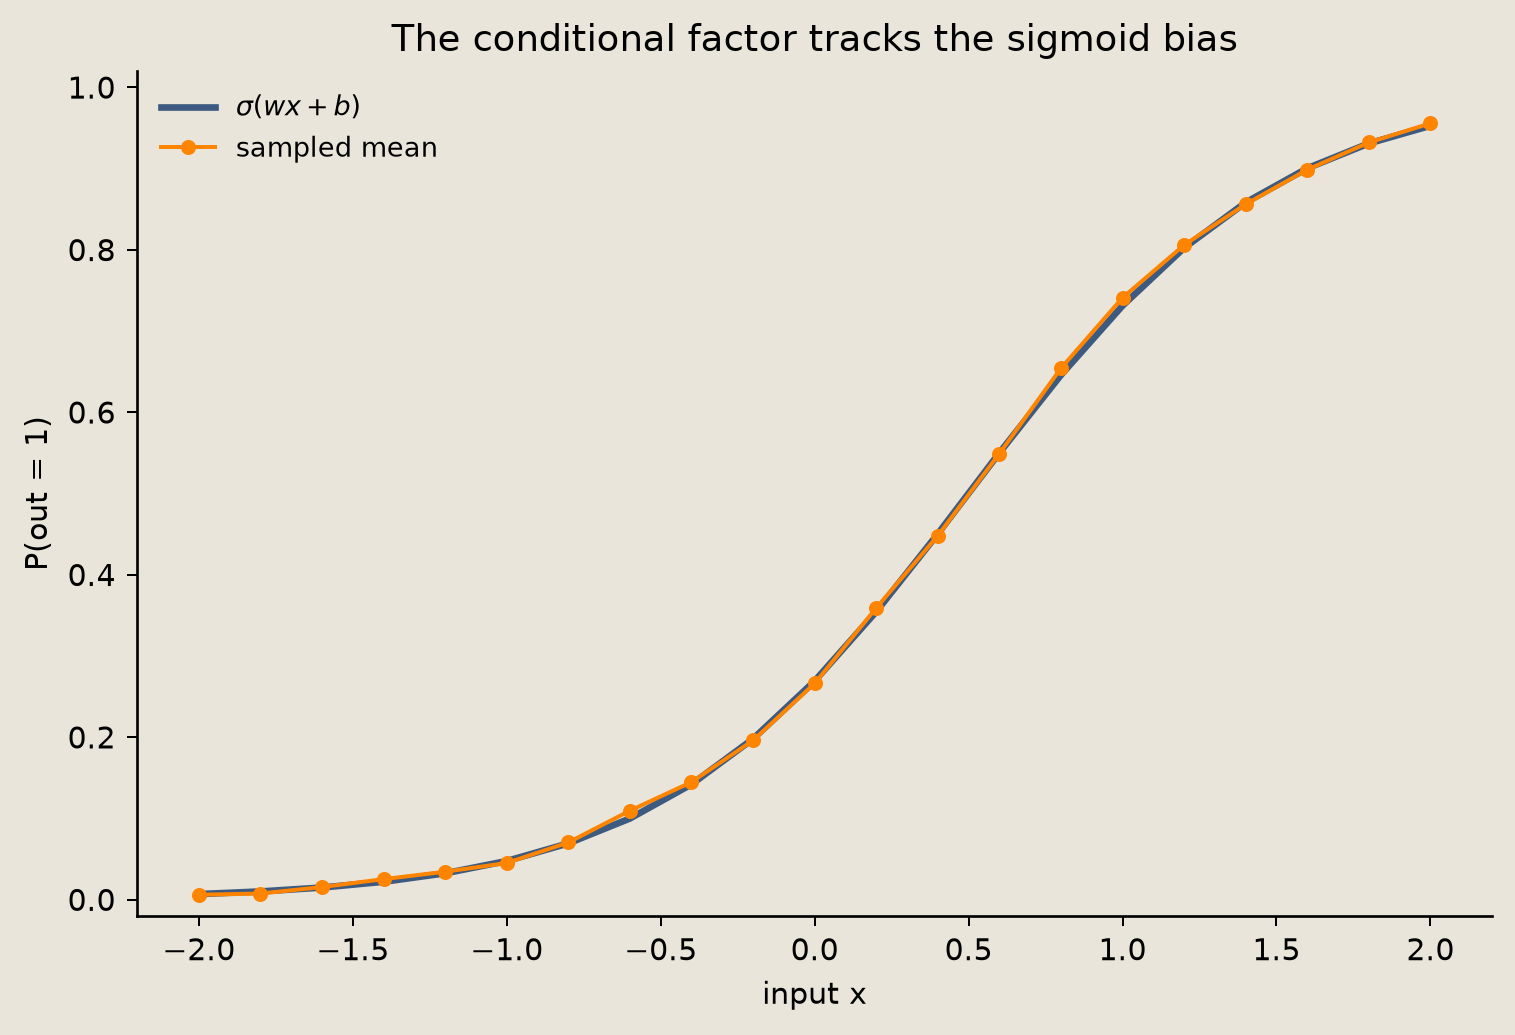

In [11]:
fig = P_samp.plot_conditional_sweep(np.asarray(xs), sampled, exact_curve)
savefig(fig, "15_conditional_sweep")

## 3. Wiring two factors into a directed factor graph

A `Site` places a factor in a graph.

It names the parents and gives a small porting function that maps parent outputs to input ports. Each `Site` also carries a `param_key`, the string `src` or `cond` here, that points to its own slice of the parameter dictionary.

A `DFG` walks its sites in topological order: parents first, then the children that depend on them. Here, `coin` draws first. Then `out` receives the coin bit on its `drive` port.

The composition rule is simple. A directed factor graph is itself a factor, with the same `sample` contract: it takes a key, the inputs, and the parameters.

The anatomy below shows that contract for a single factor: it reads any input ports and an external parameter slice, then emits one sample.

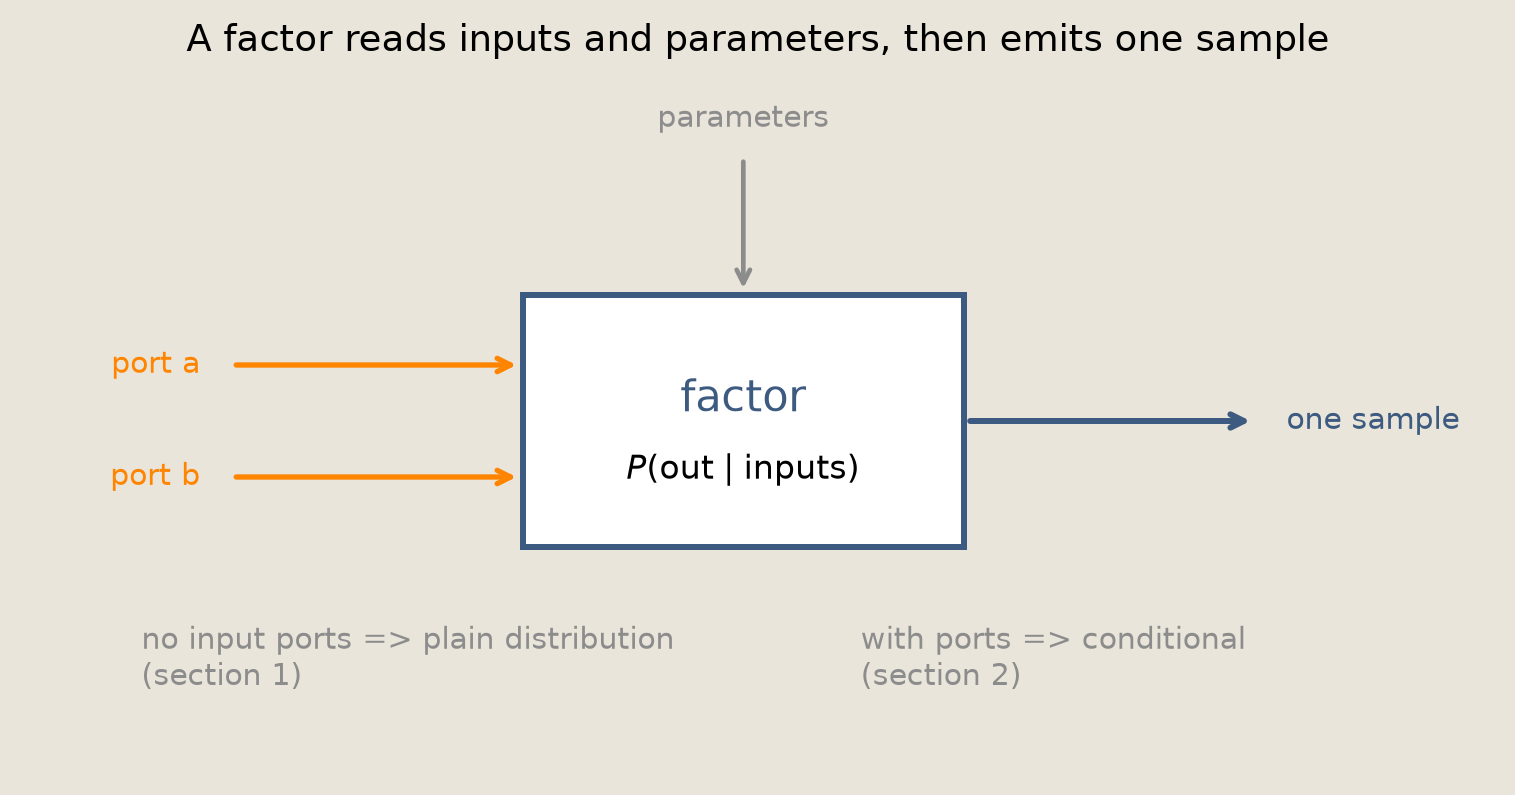

In [12]:
fig = P_sch.plot_factor_anatomy()
savefig(fig, "15_factor_anatomy")

In [13]:
def to_drive(outs):
    """Port the parent bit into the child's continuous drive input."""
    return {"drive": outs[0].astype(jnp.float32)}




In [14]:
sites = (
    # parentless coin: empty porting tuple, no parent outputs to route
    Site("coin", CoinFactor(), (), (), "src", info_key=None, site_info=None),
    Site(
        "out",
        ConditionalBit(),
        ("coin",),
        to_drive,
        "cond",
        info_key=None,
        site_info=None,
    ),
)
graph = DFG(sites, {}, "out")



In [15]:
# init_params walks the sites and returns one param slice per distinct param_key
dfg_params = graph.init_params(jax.random.key(SEED + 4))
one_draw = graph.sample(jax.random.key(SEED + 6), {}, dfg_params)
print(f"one DFG output draw: {int(one_draw)}")

keys = jax.random.split(jax.random.key(SEED + 7), 60_000)
@eqx.filter_jit
def sample_dfg_many(keys, params):
    """Draw one graph sample per key, batched under jit."""
    return jax.vmap(lambda k: graph.sample(k, {}, params))(keys)


dfg_out = sample_dfg_many(keys, dfg_params)
# Marginalize over the hidden coin by hand to check the graph sampler.
p_coin = float(jax.nn.sigmoid(dfg_params["src"]["bias"]))
w, b = dfg_params["cond"]["w"], dfg_params["cond"]["b"]
p_out_g0 = float(jax.nn.sigmoid(w * 0 + b))
p_out_g1 = float(jax.nn.sigmoid(w * 1 + b))
p_out_exact = (1 - p_coin) * p_out_g0 + p_coin * p_out_g1
p_out_emp = float(dfg_out.mean())
print(f"hand-computed P(out=1) = {p_out_exact:.3f}   sampled = {p_out_emp:.3f}")

one DFG output draw: 1
hand-computed P(out=1) = 0.546   sampled = 0.549


The sampled graph mean lands on the hand-marginalized value, so the two-node `DFG` composes its factors correctly.

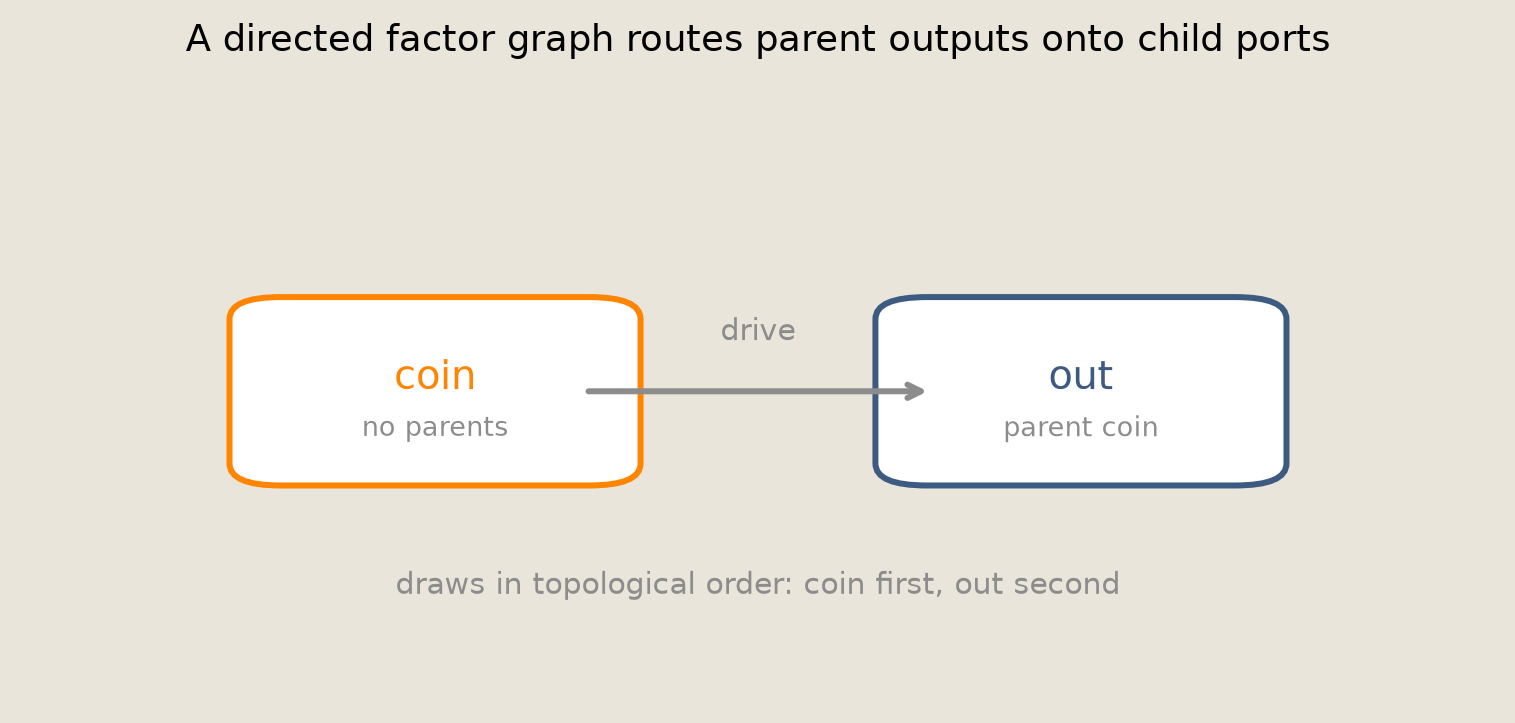

In [16]:
fig = P_sch.plot_two_node_dfg()
savefig(fig, "15_two_node_dfg")

## 4. Exact probabilities as an opt-in capability

Sampling is the common contract.

Some finite factors can also report exact probabilities. This small example is one pdit with $d=3$ states. It implements the `get_log_probability_matrix` method and prints the probability table. `AbstractMatrixFactor` leaves sampling abstract, so this example defines both the exact matrix and the sampler.

With no inputs, the table has a single row. The comparison below puts sampled frequencies next to that exact row.

In [17]:
class TinyCategorical(AbstractMatrixFactor):
    """A finite 3-state pdit, no inputs, that also reports exact probabilities."""

    input_states: dict[str, jax.Array]
    output_states: dict[str, jax.Array]
    sampler: JaxPRNGSampler

    def __init__(self):
        self.input_states = {}
        self.output_states = {"x": jnp.arange(3)}
        self.sampler = JaxPRNGSampler()

    def init_params(self, key):
        return {"logits": jnp.array([0.2, 1.0, -0.5])}

    def sample(self, key, inputs, params, info=None, site_info=None, return_aux=False):
        row = self.get_log_probability_matrix(params, info, site_info)[0]
        out = self.get_nth_output_state(self.sampler.categorical(key, row))
        return (out, None) if return_aux else out

    def get_log_probability_matrix(self, params, info=None, site_info=None):
        logits = params["logits"]
        return (logits - jax.scipy.special.logsumexp(logits))[None, :]

In [18]:
cat = TinyCategorical()
cat_params = cat.init_params(jax.random.key(SEED + 8))
exact_p = np.asarray(jnp.exp(cat.get_log_probability_matrix(cat_params))[0])
print("exact probabilities:")
for s, p in enumerate(exact_p):
    print(f"  P(x = {s}) = {p:.3f}")
print(f"  sum        = {exact_p.sum():.3f}")

keys = jax.random.split(jax.random.key(SEED + 18), 50_000)
cat_draws = jax.vmap(lambda k: cat.sample(k, {}, cat_params))(keys)["x"]
# Compare the exact row with frequencies from many categorical draws.
emp_p = np.asarray(jax.vmap(lambda s: jnp.mean(cat_draws == s))(jnp.arange(3)))

exact probabilities:
  P(x = 0) = 0.269
  P(x = 1) = 0.598
  P(x = 2) = 0.133
  sum        = 1.000


The sampled frequencies land on the exact row, so the opt-in probability table and the sampling contract describe the same distribution. The parity figure below plots the two side by side.

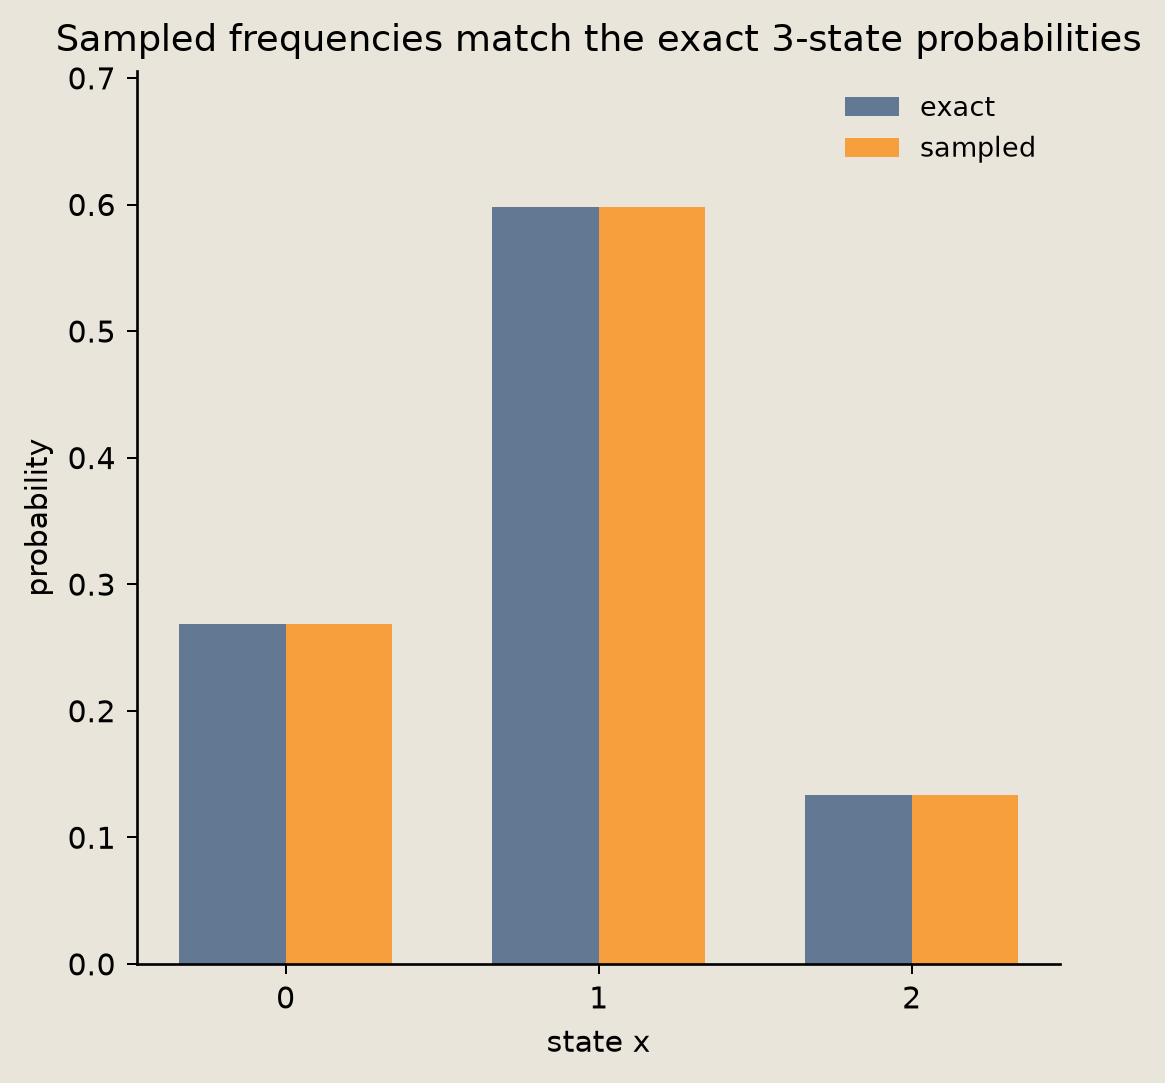

In [19]:
fig = P_samp.plot_categorical_parity(exact_p, emp_p)
savefig(fig, "15_categorical_parity")

## 5. Copying and repeating with composite factors

Two composite factors keep common patterns short.

The `TiledFactor` class runs independent copies of a factor in parallel. The `ChainFactor` class repeats a transition and feeds the previous output back into one named input.

The `feedback_porting_fn` argument routes each step's output into the next step's inputs: a port-name string sends the whole output to that input. A non-feedback input is held fixed at every step. That is how [notebook 16](16_gibbs_sampling_factor_graph.ipynb) keeps the field constant while spins evolve.

This small chain is the same object as the chain factor in notebook 16, with one pbit transition in place of a 16-spin sweep.

In [20]:
class FlipFactor(AbstractReferenceFactor):
    """P(next | state): a 2-state telegraph step. Input port and output are both pbits."""

    input_ports: dict[str, jax.ShapeDtypeStruct] = eqx.field(static=True)
    output_spec: jax.ShapeDtypeStruct = eqx.field(static=True)
    sampler: JaxPRNGSampler

    def __init__(self):
        self.input_ports = {"state": BIT}  # same dtype as the output: int to int
        self.output_spec = BIT
        self.sampler = JaxPRNGSampler()

    def init_params(self, key):
        return {"w": jnp.array(1.5), "b": jnp.array(0.0)}

    def sample(self, key, inputs, params, info=None, site_info=None, return_aux=False):
        gamma = params["b"] + params["w"] * (2 * inputs["state"] - 1)
        out = self.sampler.bernoulli(key, jax.nn.sigmoid(gamma))
        return (out, None) if return_aux else out

In [21]:
flip = FlipFactor()
flip_params = flip.init_params(jax.random.key(SEED + 9))

# parallel: 8 independent copies under one vmapped call
tiled = TiledFactor(flip, n_tiles=8, weight_tied=True)
tiled_out = tiled.sample(
    jax.random.key(SEED + 10), {"state": jnp.zeros(8, jnp.int32)}, flip_params
)

# repeat: feed the output back as the next input, 5 steps, one shared parameter set
chain = ChainFactor(flip, n_steps=5, feedback_porting_fn="state", weight_tied=True)
chain_out = chain.sample(
    jax.random.key(SEED + 11), {"state": jnp.array(0, jnp.int32)}, flip_params
)
print(f"tiled 8 parallel draws: {np.asarray(tiled_out)}")
print(f"chain after 5 steps:    {int(chain_out)}")

tiled 8 parallel draws: [1 0 0 0 1 0 1 0]
chain after 5 steps:    1


Both composites run: the tile returns eight parallel draws and the chain returns the state after five fed-back steps, each through the same `sample` contract as the single factor.

## 6. The factor-to-circuit ladder

The ladder is visible now.

A factor is a sampler. It may be conditional, and finite factors may also be exact. A directed factor graph can be any DAG of factors sampled ancestrally. The worked example here is the two-node chain version, where each node is drawn once its parent is available. The graph is itself a factor.

A PSC is the circuit-shaped specialization of the same idea, built from local gates in [notebook 01](01_introduction_to_parametrised_stochastic_circuits.ipynb).

A real model can use the factor level directly, as [notebook 16](16_gibbs_sampling_factor_graph.ipynb) does for a 16-spin Ising model and its exact Boltzmann machine reference.

## Verification

Finally, we assert the estimates computed above against their exact values, and add deterministic same-key checks for the composite factors: `TiledFactor` must equal a manual `vmap` over split keys, and `ChainFactor` must equal a manual scan that feeds each step's output back with the same split keys.

In [22]:
COIN_MEAN_TOL = 0.02  # ~5 sigma at N=20000
COND_SWEEP_TOL = 0.03  # finite-sample
DFG_MEAN_TOL = 0.02  # finite-sample
CAT_FREQ_TOL = 0.02  # finite-sample
CHAIN_MEAN_TOL = 0.03  # finite-sample



In [23]:
assert abs(coin_mean - coin_target) < COIN_MEAN_TOL, (coin_mean, coin_target)
assert np.max(np.abs(sampled - exact_curve)) < COND_SWEEP_TOL
assert abs(p_out_emp - p_out_exact) < DFG_MEAN_TOL, (p_out_emp, p_out_exact)
assert abs(exact_p.sum() - 1.0) < 1e-5
assert np.max(np.abs(emp_p - exact_p)) < CAT_FREQ_TOL, (emp_p, exact_p)



In [24]:
# deterministic same-key check: TiledFactor == manual vmap over split keys
tiled_ref = jax.vmap(
    lambda k: flip.sample(k, {"state": jnp.array(0, jnp.int32)}, flip_params)
)(jax.random.split(jax.random.key(SEED + 10), 8))
np.testing.assert_array_equal(np.asarray(tiled_out), np.asarray(tiled_ref))



In [25]:
# deterministic same-key check: ChainFactor(n_steps=5) == manual feedback scan
manual_state = jnp.array(0, jnp.int32)
for step_key in jax.random.split(jax.random.key(SEED + 11), 5):
    manual_state = flip.sample(step_key, {"state": manual_state}, flip_params)
assert int(chain_out) == int(manual_state), (int(chain_out), int(manual_state))



In [26]:
chain1 = ChainFactor(flip, n_steps=1, feedback_porting_fn="state", weight_tied=True)
seed_state = jnp.array(0, jnp.int32)
chain_keys = jax.random.split(jax.random.key(SEED + 12), 20_000)
flip_keys = jax.random.split(jax.random.key(SEED + 13), 20_000)
chain1_draws = jax.vmap(lambda k: chain1.sample(k, {"state": seed_state}, flip_params))(
    chain_keys
)
flip_draws = jax.vmap(lambda k: flip.sample(k, {"state": seed_state}, flip_params))(
    flip_keys
)
assert abs(float(chain1_draws.mean() - flip_draws.mean())) < CHAIN_MEAN_TOL
# ChainFactor splits step keys internally.
chain_key = jax.random.key(SEED + 12)
one_step = chain1.sample(chain_key, {"state": seed_state}, flip_params)
single = flip.sample(
    jax.random.split(chain_key, 1)[0], {"state": seed_state}, flip_params
)
assert int(one_step) == int(single), (one_step, single)
print("all checks passed")

all checks passed


## Conclusion

We built the factor side of Torx from one sampler up to a small directed factor graph.

A factor starts as a sampler. Input ports turn it into a conditional. `Site` objects wire factors into a `DFG`, and the graph remains a factor you can sample.

Exact probabilities are optional, and they are useful at small scale. The `TiledFactor` class copies a transition in parallel, while the `ChainFactor` class repeats it through time.

For the circuit-shaped view, go back to [notebook 01](01_introduction_to_parametrised_stochastic_circuits.ipynb). For the larger Ising model worked example, continue to [notebook 16](16_gibbs_sampling_factor_graph.ipynb).